# MODEL PIPELINE - Data Type Profiler
1. Load libraries
2. Setup training pipelines for Tree and Neural Network models
3. Load data
4. Initialize models
5. Train models
6. Compare results

## 1. Load Libraries

In [2]:
import time
import random
import numpy as np
import pandas as pd
from itertools import product
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.metrics import geometric_mean_score

from model.tree_model import TreeModel
from model.modular_neural_network_model import ModularNeuralNetwork
from model.stats_neural_network import StatsNeuralNetwork
from model.col_name_neural_network import ColNameNeuralNetwork

## 2. Training Pipelines

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cpu


### 2.1 Tree Model Pipeline

In [4]:
def tree_model_training_pipeline(X_train, y_train, X_val, y_val, X_test, y_test, model, X_test_column):
    start_time = time.time()

    model.train(X_train, y_train)
    model.evaluate(X_train, y_train, X_val, y_val, X_test, y_test, X_test_column)

    training_time = time.time() - start_time

    print(f"Training completed in {training_time:.2f} seconds")
    print(f"Train Accuracy      : {model.metrics['train_accuracy']:.2f}%")
    print(f"Validation Accuracy : {model.metrics['validation_accuracy']:.2f}%")
    print(f"Validation G-Mean   : {model.metrics['validation_gmean']:.4f}")

### 2.2 Neural Network Pipeline

In [5]:
def nn_model_training_pipeline(X_train, y_train, X_val, y_val, X_test, y_test, X_test_column, model,
                                epochs=50, batch_size=32, lr=0.001, weight_decay=1e-3,
                                patience=10, min_delta=0.001, monitor="val_gmean"):
    start_time = time.time()
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model.prep_data_loader(X_train, y_train, X_val, y_val, X_test, y_test, batch_size)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    model.train_epochs(optimizer, scheduler, epochs, device, patience, min_delta, monitor)
    model.evaluate(X_test_column, device)

    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.2f} seconds")
    print(f"Best Validation {monitor}: {model.metrics['best_val_metric']:.4f}")

    return model

## 3. Load Data

In [6]:
LABELENCODER = {
    'varchar':   '0',
    'number':    '1',
    'boolean':   '2',
    'time':      '3',
    'date':      '3',
    'timestamp': '3',
}

X_train = pd.read_csv('data/X_train.csv')
X_train = X_train.drop(columns=['ColumnName'])
y_train_labels = pd.read_csv('data/y_train.csv')
y_train = y_train_labels['DataType'].map(LABELENCODER).to_frame(name="DataType")

X_val = pd.read_csv('data/X_val.csv')
X_val = X_val.drop(columns=['ColumnName'])
y_val_labels = pd.read_csv('data/y_val.csv')
y_val = y_val_labels['DataType'].map(LABELENCODER).to_frame(name="DataType")

X_test = pd.read_csv('data/X_test.csv')
X_test_column = X_test['ColumnName']
X_test = X_test.drop(columns=['ColumnName'])
y_test_labels = pd.read_csv('data/y_test.csv')
y_test = y_test_labels['DataType'].map(LABELENCODER).to_frame(name="DataType")

feature_cols = X_train.columns


## 4. Initialise Models

### 4.1 Decision Tree

In [7]:
dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    criterion='gini',
    random_state=42,
)
dt_model = TreeModel("Decision Tree", dt)

### 4.2 Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    criterion='gini',
    n_jobs=-1,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    class_weight="balanced",
)
rf_model = TreeModel("Random Forest", rf)

### 4.3 Class Weights and Loss Function for Neural Networks

In [9]:
class_counts = Counter(y_train['DataType'])
num_classes   = len(class_counts)

counts         = [class_counts[str(i)] for i in range(num_classes)]
counts_tensor  = torch.tensor(counts, dtype=torch.float32)
class_weights  = 1.0 / torch.sqrt(counts_tensor)
class_weights  = class_weights / class_weights.sum() * num_classes

print("Class counts :", class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

Class counts : Counter({'1': 987, '0': 961, '3': 143, '2': 142})
Class weights: tensor([0.5571, 0.5497, 1.4492, 1.4441])


## 5. Train Models

### 5.1 Decision Tree

In [10]:
tree_model_training_pipeline(X_train, y_train, X_val, y_val, X_test, y_test, dt_model, X_test_column)

Training Decision Tree...

Decision Tree - Misclassified indices: [  0  13  15  20  42  52  59  65  70  71  75  82  90  92 129 137 170 176
 189 192 195 204 238 268 273]
Total misclassifications: 25

Misclassified samples with predictions:
                       Feature_Value Actual Predicted
0                               year      0         1
1                             UserId      0         1
2                   Insurance Number      0         1
3                               name      0         1
4                                mcc      0         1
5                          dti_joint      1         0
6                             errors      0         1
7                        fiscal_year      1         0
8                     acct_open_date      0         1
9                   num_cards_issued      1         0
10                               bid      0         1
11                          'Symbol'      0         2
12                           captive      2         0
13   

### 5.2 Random Forest

In [11]:
tree_model_training_pipeline(X_train, y_train, X_val, y_val, X_test, y_test, rf_model, X_test_column)

Training Random Forest...



Random Forest - Misclassified indices: [ 13  15  42  63  70  75 122 170 176 189 192 195 211 217]
Total misclassifications: 14

Misclassified samples with predictions:
                       Feature_Value Actual Predicted
0                             UserId      0         1
1                   Insurance Number      0         1
2                                mcc      0         1
3                           discount      1         2
4                     acct_open_date      0         3
5                                bid      0         1
6                         Individual      2         0
7                         CustomerNo      0         1
8                    identifications      0         1
9                             labels      0         2
10                        fraud_flag      2         0
11                   Transaction Zip      0         1
12                'controller_reord'      1         2
13  num_identification_disagreements      1         2
Training completed in 

### 5.3 Feature Importance: Random Forest vs Decision Tree

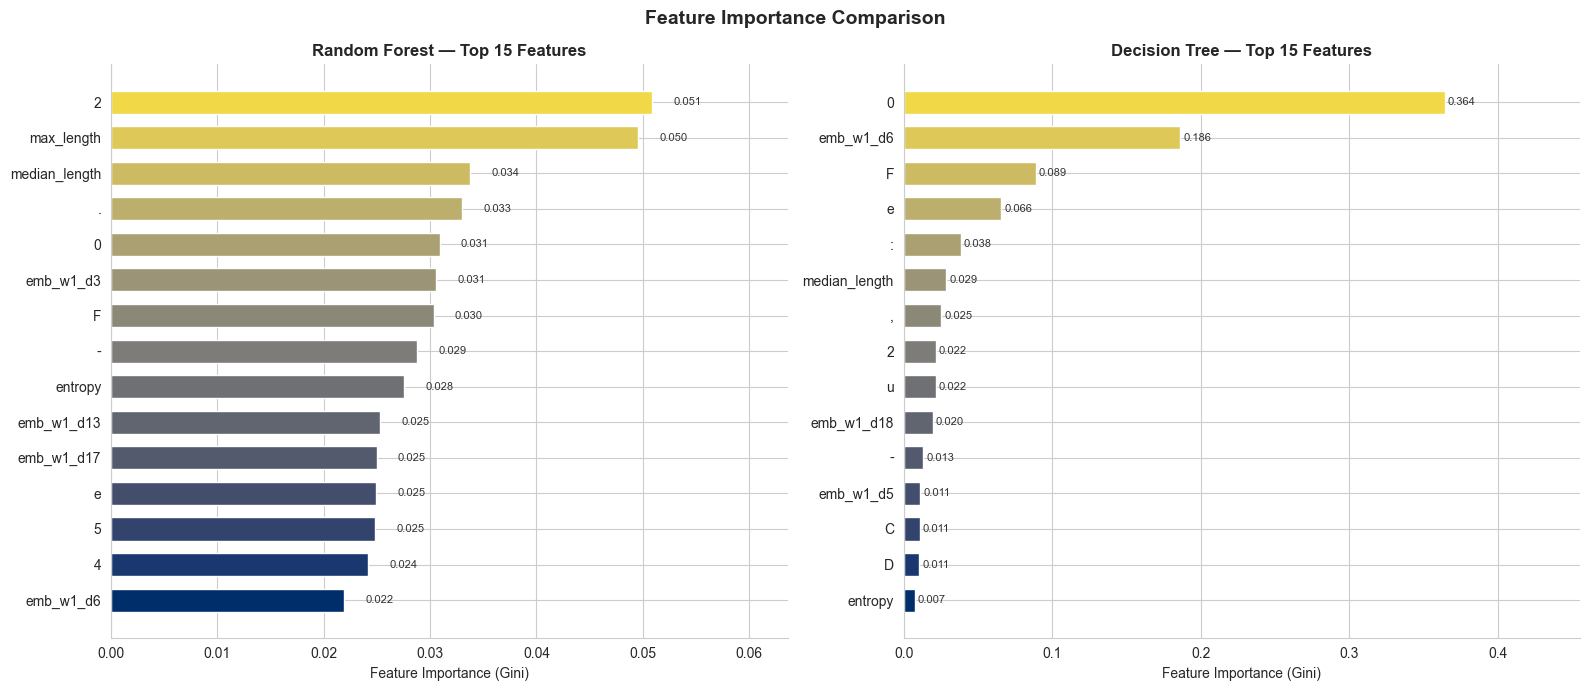

In [12]:
def plot_feature_importance(model, feature_names, top_n=15, ax=None, title=None):
    importances = model.model.feature_importances_
    top_n   = min(top_n, len(importances))
    indices = np.flip(np.argsort(importances)[-top_n:])

    importance_df = pd.DataFrame({
        'Feature':    [feature_names[i] for i in indices],
        'Importance': importances[indices],
    })

    has_std = hasattr(model.model, 'estimators_')
    if has_std:
        std = np.std([t.feature_importances_ for t in model.model.estimators_], axis=0)
        importance_df['Std'] = std[indices]

    standalone = ax is None
    if standalone:
        _, ax = plt.subplots(figsize=(7, 6))

    colors = sns.color_palette('cividis', top_n)[::-1]
    bars = ax.barh(
        importance_df['Feature'],
        importance_df['Importance'],
        color=colors,
        error_kw=dict(ecolor='#555555', capsize=3, capthick=1, elinewidth=1),
        height=0.65,
    )

    for bar, val in zip(bars, importance_df['Importance']):
        ax.text(
            bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=8, color='#333333',
        )

    ax.set_xlabel('Feature Importance (Gini)', fontsize=10)
    ax.set_ylabel('')
    ax.set_title(title or f'Top {top_n} Feature Importances', fontsize=12, fontweight='bold')
    ax.set_xlim(0, importance_df['Importance'].max() * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_yaxis()

    if standalone:
        plt.tight_layout()
        plt.savefig('feature_importance.pdf', bbox_inches='tight', dpi=300)
        plt.show()


feature_names = list(X_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_feature_importance(rf_model, feature_names, top_n=15, ax=axes[0],
                        title='Random Forest — Top 15 Features')
plot_feature_importance(dt_model, feature_names, top_n=15, ax=axes[1],
                        title='Decision Tree — Top 15 Features')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('feature_importance_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### 5.4 Neural Network Hyperparameter Search

In [13]:
learning_rates = [0.0005, 0.0003, 0.003, 0.005, 0.001]
batch_sizes    = [512, 1024]
epochs         = 500

total_combinations = len(learning_rates) * len(batch_sizes)
current_combo      = 0
modular_nn_models  = []
best_models        = {}

for lr, batch_size in product(learning_rates, batch_sizes):
    current_combo += 1
    print(f"\n{'='*70}")
    print(f"Combination {current_combo}/{total_combinations}  |  lr={lr}, batch_size={batch_size}")
    print(f"{'='*70}\n")

    modular_nn_model = ModularNeuralNetwork(criterion).to(device)

    nn_model_training_pipeline(
        X_train, y_train, X_val, y_val, X_test, y_test, X_test_column,
        modular_nn_model, epochs=epochs, batch_size=batch_size,
        lr=lr, patience=75, weight_decay=1e-4, min_delta=0.001,
        monitor="val_gmean",
    )

    modular_nn_models.append({'lr': lr, 'batch_size': batch_size} | modular_nn_model.metrics)
    best_models[(lr, batch_size)] = modular_nn_model

results_df = pd.DataFrame(modular_nn_models)


Combination 1/10  |  lr=0.0005, batch_size=512



Epoch [1/500] - New best validation G-Mean: 0.6010
Epoch [2/500] - New best validation G-Mean: 0.6830
Epoch [3/500] - New best validation G-Mean: 0.7408
Epoch [4/500] - New best validation G-Mean: 0.7669
Epoch [5/500] - New best validation G-Mean: 0.8003
Epoch [6/500] - New best validation G-Mean: 0.8431
Epoch [7/500] - New best validation G-Mean: 0.8620
Epoch [8/500] - New best validation G-Mean: 0.8713
Epoch [9/500] - New best validation G-Mean: 0.8746
Epoch [10/500] - New best validation G-Mean: 0.8810
Epoch [10/500] - Train Loss: 0.8789, Train Acc: 83.83% | Val Loss: 0.8583, Val Acc: 82.81%, Val G-Mean(weighted): 0.8810 | No improve: 0/75
Epoch [11/500] - New best validation G-Mean: 0.8889
Epoch [12/500] - New best validation G-Mean: 0.8933
Epoch [13/500] - New best validation G-Mean: 0.8972
Epoch [16/500] - New best validation G-Mean: 0.9023
Epoch [17/500] - New best validation G-Mean: 0.9077
Epoch [18/500] - New best validation G-Mean: 0.9116
Epoch [20/500] - New best validation 

### 5.5 Ensemble: Tune Alpha on Validation Set, Evaluate on Test Set

Best NN: lr=0.001, batch_size=512, val_gmean=0.9484

Tuning ensemble alpha on validation set...
  alpha=0.05 → Val G-Mean: 0.9620
  alpha=0.10 → Val G-Mean: 0.9645
  alpha=0.15 → Val G-Mean: 0.9635
  alpha=0.20 → Val G-Mean: 0.9711
  alpha=0.30 → Val G-Mean: 0.9714
  alpha=0.50 → Val G-Mean: 0.9468
  alpha=0.70 → Val G-Mean: 0.9266

Best alpha: 0.3  (Val G-Mean: 0.9714)


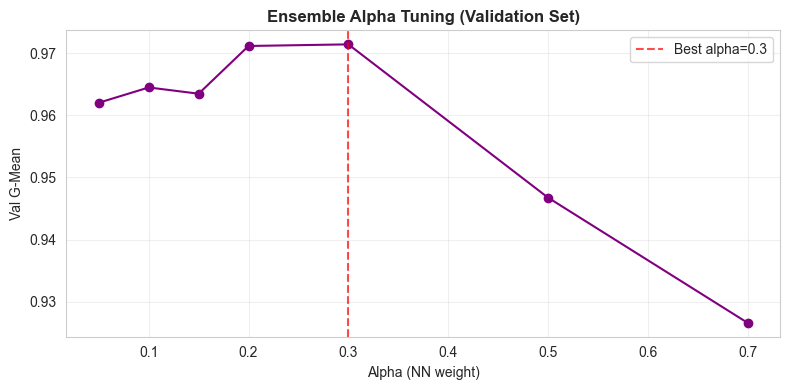


Evaluating ensemble on test set with alpha=0.3...
Ensemble Test G-Mean  : 0.9562
Ensemble Test Accuracy: 96.88%


In [14]:
# Select best NN by validation G-Mean
best_nn_idx = results_df['best_val_metric'].idxmax()
best_nn_row = results_df.loc[best_nn_idx]
best_lr     = best_nn_row['lr']
best_bs     = int(best_nn_row['batch_size'])

print(f"Best NN: lr={best_lr}, batch_size={best_bs}, val_gmean={best_nn_row['best_val_metric']:.4f}")

best_nn = best_models[(best_lr, best_bs)]

# --- Tune alpha on validation set ---
print("\nTuning ensemble alpha on validation set...")
alpha_results = []
for alpha in [0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.7]:
    best_nn.evaluate_ensemble(rf_model, X_val, alpha=alpha, device=device, split='val')
    val_gmean = best_nn.metrics['ensemble_test_gmean']
    alpha_results.append({'alpha': alpha, 'val_gmean': val_gmean})
    print(f"  alpha={alpha:.2f} → Val G-Mean: {val_gmean:.4f}")

alpha_df  = pd.DataFrame(alpha_results)
best_alpha = alpha_df.loc[alpha_df['val_gmean'].idxmax(), 'alpha']
print(f"\nBest alpha: {best_alpha}  (Val G-Mean: {alpha_df['val_gmean'].max():.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alpha_df['alpha'], alpha_df['val_gmean'], marker='o', color='purple')
ax.axvline(x=best_alpha, color='red', linestyle='--', alpha=0.7, label=f'Best alpha={best_alpha}')
ax.set_xlabel('Alpha (NN weight)')
ax.set_ylabel('Val G-Mean')
ax.set_title('Ensemble Alpha Tuning (Validation Set)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ensemble_alpha_tuning.pdf', bbox_inches='tight', dpi=300)
plt.savefig('ensemble_alpha_tuning.png', bbox_inches='tight', dpi=300)
plt.show()

# --- Evaluate once on test set ---
print(f"\nEvaluating ensemble on test set with alpha={best_alpha}...")
best_nn.evaluate_ensemble(rf_model, X_test, alpha=best_alpha, device=device, split='test')
print(f"Ensemble Test G-Mean  : {best_nn.metrics['ensemble_test_gmean']:.4f}")
print(f"Ensemble Test Accuracy: {best_nn.metrics['ensemble_test_accuracy']:.2f}%")

## 6. Results

### 6.1 Neural Network Hyperparameter Analysis

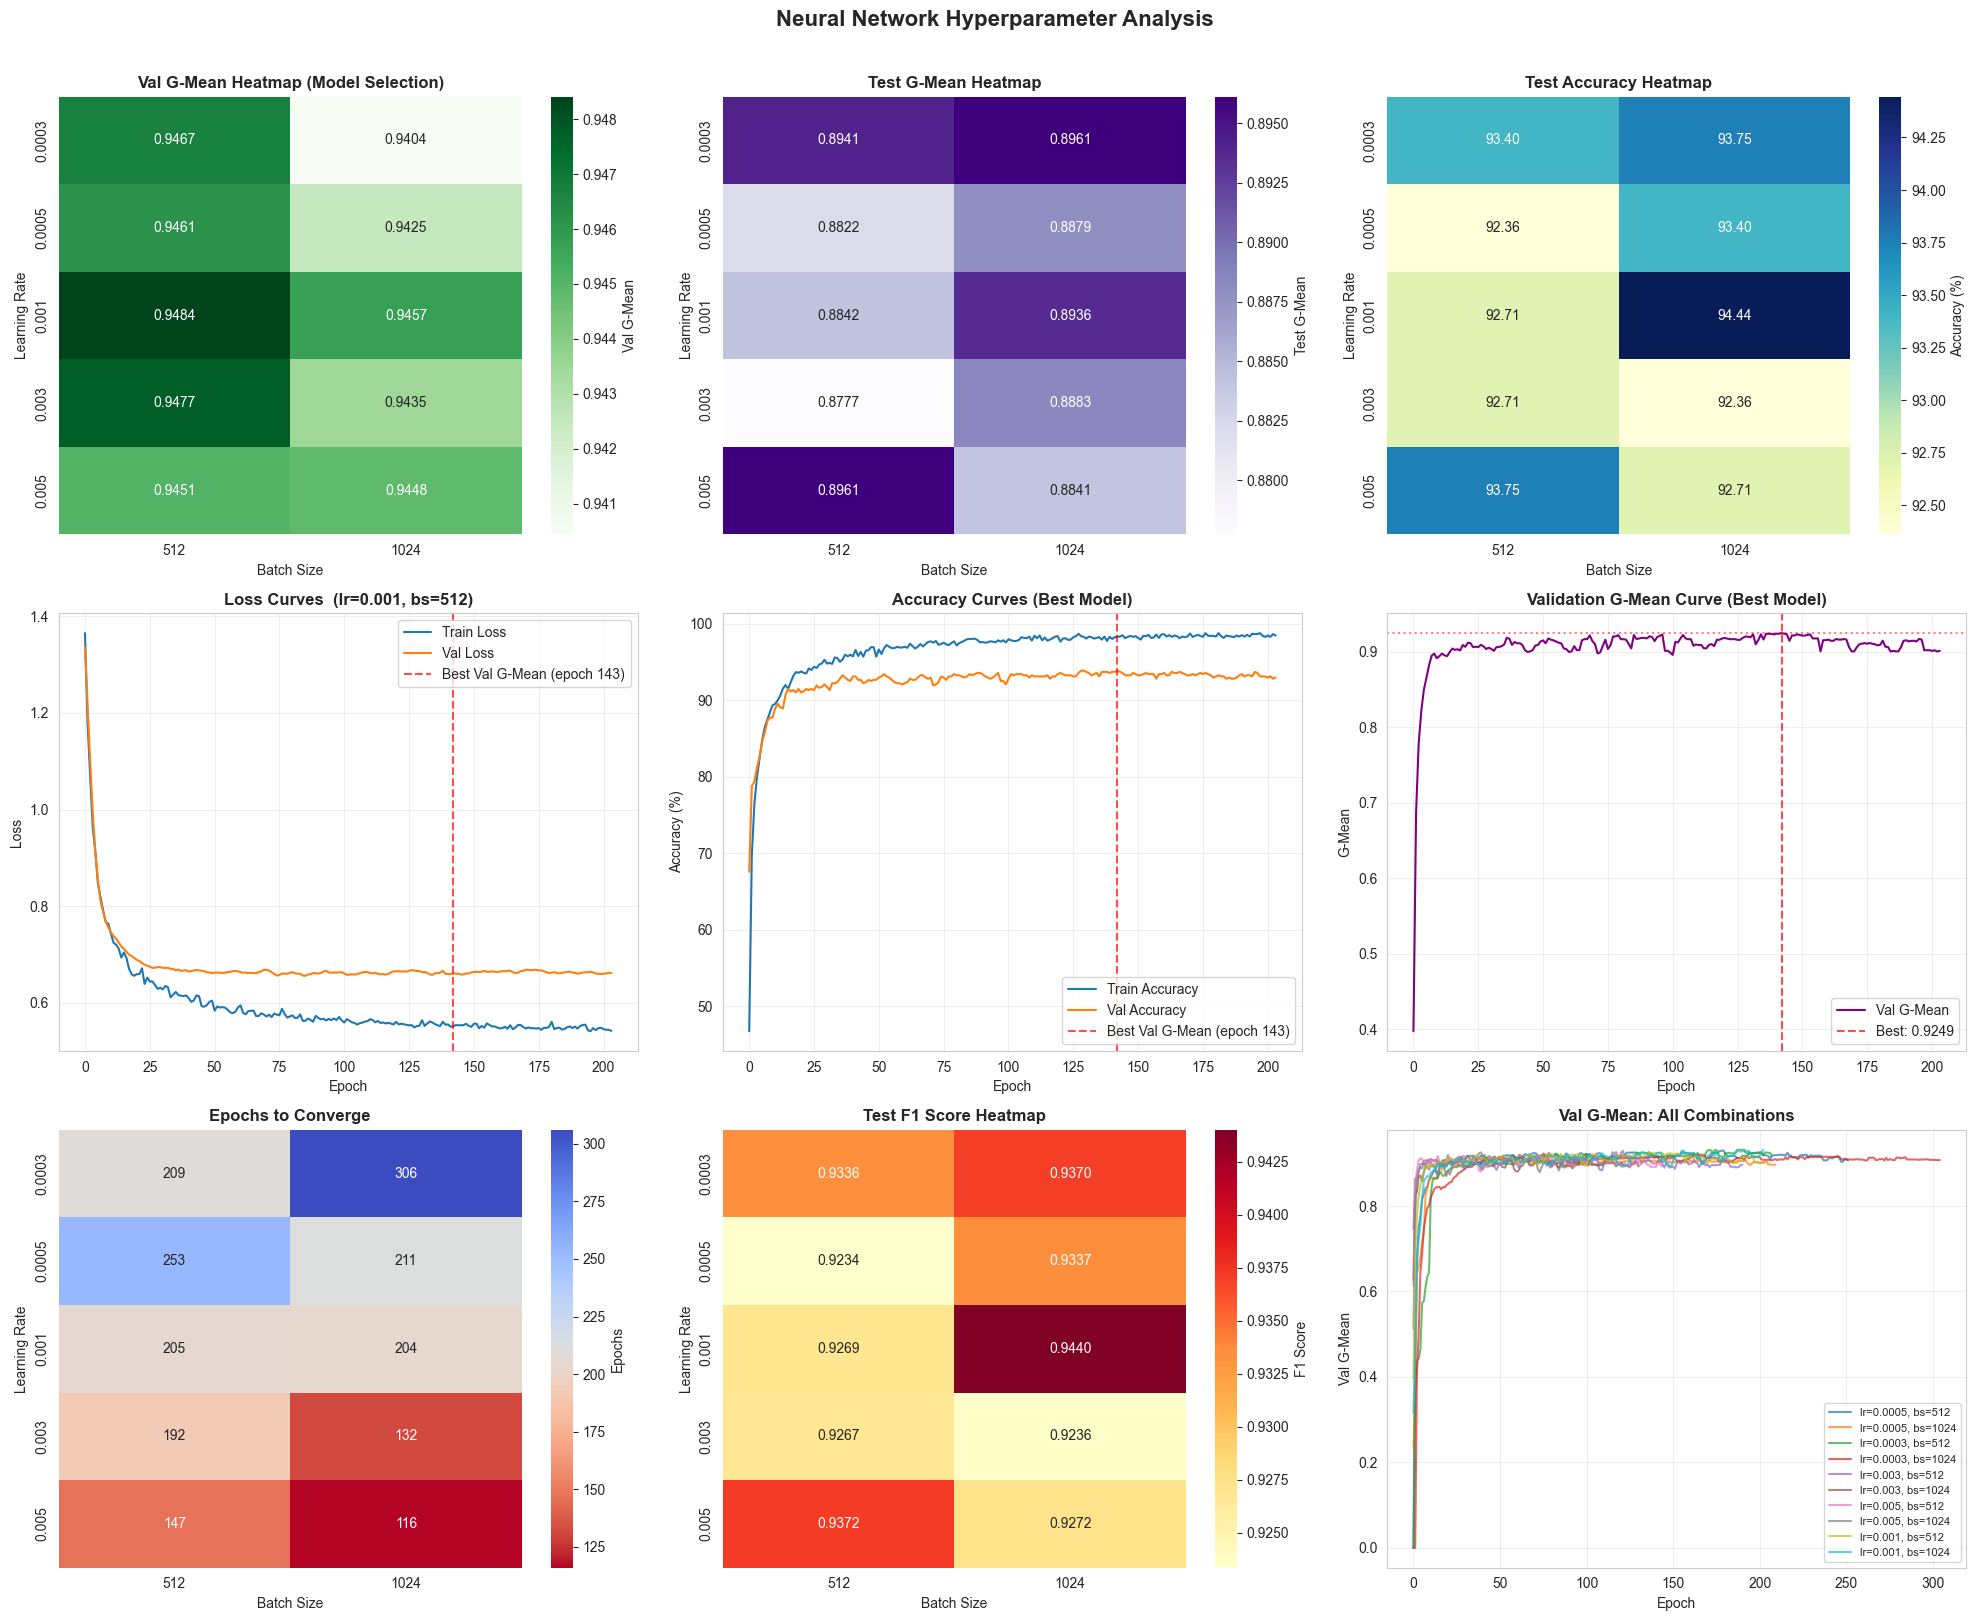

In [15]:
best_model_metrics = results_df.loc[results_df['best_val_metric'].idxmax()]

fig = plt.figure(figsize=(20, 16))

# Row 1: Heatmaps
plt.subplot(3, 3, 1)
pivot_val_gmean = results_df.pivot(index='lr', columns='batch_size', values='best_val_metric')
sns.heatmap(pivot_val_gmean, annot=True, fmt='.4f', cmap='Greens', cbar_kws={'label': 'Val G-Mean'})
plt.title('Val G-Mean Heatmap (Model Selection)', fontsize=12, fontweight='bold')
plt.xlabel('Batch Size'); plt.ylabel('Learning Rate')

plt.subplot(3, 3, 2)
pivot_gmean = results_df.pivot(index='lr', columns='batch_size', values='test_gmean')
sns.heatmap(pivot_gmean, annot=True, fmt='.4f', cmap='Purples', cbar_kws={'label': 'Test G-Mean'})
plt.title('Test G-Mean Heatmap', fontsize=12, fontweight='bold')
plt.xlabel('Batch Size'); plt.ylabel('Learning Rate')

plt.subplot(3, 3, 3)
pivot_accuracy = results_df.pivot(index='lr', columns='batch_size', values='test_accuracy')
sns.heatmap(pivot_accuracy, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Accuracy (%)'})
plt.title('Test Accuracy Heatmap', fontsize=12, fontweight='bold')
plt.xlabel('Batch Size'); plt.ylabel('Learning Rate')

# Row 2: Training curves for best model
train_losses     = best_model_metrics['train_losses']
val_losses       = best_model_metrics['val_losses']
train_accs       = best_model_metrics['train_accuracies']
val_accs         = best_model_metrics['val_accuracies']
val_gmeans       = best_model_metrics['val_gmeans']
best_gmean_epoch = val_gmeans.index(max(val_gmeans))

plt.subplot(3, 3, 4)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.axvline(x=best_gmean_epoch, color='red', linestyle='--', alpha=0.7,
            label=f'Best Val G-Mean (epoch {best_gmean_epoch + 1})')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title(f'Loss Curves  (lr={best_model_metrics["lr"]}, bs={best_model_metrics["batch_size"]})',
          fontsize=12, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 5)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs,   label='Val Accuracy')
plt.axvline(x=best_gmean_epoch, color='red', linestyle='--', alpha=0.7,
            label=f'Best Val G-Mean (epoch {best_gmean_epoch + 1})')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curves (Best Model)', fontsize=12, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 6)
plt.plot(val_gmeans, label='Val G-Mean', color='purple')
plt.axvline(x=best_gmean_epoch, color='red', linestyle='--', alpha=0.7,
            label=f'Best: {max(val_gmeans):.4f}')
plt.axhline(y=max(val_gmeans), color='red', linestyle=':', alpha=0.5)
plt.xlabel('Epoch'); plt.ylabel('G-Mean')
plt.title('Validation G-Mean Curve (Best Model)', fontsize=12, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)

# Row 3: Convergence + F1 heatmap + all G-Mean curves
plt.subplot(3, 3, 7)
pivot_epochs = results_df.pivot(index='lr', columns='batch_size', values='stopped_epoch')
sns.heatmap(pivot_epochs, annot=True, fmt='.0f', cmap='coolwarm_r', cbar_kws={'label': 'Epochs'})
plt.title('Epochs to Converge', fontsize=12, fontweight='bold')
plt.xlabel('Batch Size'); plt.ylabel('Learning Rate')

plt.subplot(3, 3, 8)
pivot_f1 = results_df.pivot(index='lr', columns='batch_size', values='test_f1score')
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'F1 Score'})
plt.title('Test F1 Score Heatmap', fontsize=12, fontweight='bold')
plt.xlabel('Batch Size'); plt.ylabel('Learning Rate')

plt.subplot(3, 3, 9)
for _, row in results_df.iterrows():
    plt.plot(row['val_gmeans'], label=f"lr={row['lr']}, bs={row['batch_size']}", alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('Val G-Mean')
plt.title('Val G-Mean: All Combinations', fontsize=12, fontweight='bold')
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)

plt.suptitle('Neural Network Hyperparameter Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nn_hyperparameter_analysis.pdf', bbox_inches='tight', dpi=300)
plt.savefig('nn_hyperparameter_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

### 6.2 Pandas Baseline

In [16]:
PANDAS_LABELENCODER = {
    'object':         '0',  # varchar
    'int64':          '1',  # number
    'float64':        '1',
    'int32':          '1',
    'float32':        '1',
    'bool':           '2',  # boolean
    'datetime64[ns]': '3',  # datetime
    'timedelta[ns]':  '3',
}

y_pandas_labels  = pd.read_csv('data/y_pandas.csv')
y_pandas_encoded = y_pandas_labels['PandasDataType'].map(PANDAS_LABELENCODER)

unmapped = y_pandas_labels['PandasDataType'][y_pandas_encoded.isna()].unique()
if len(unmapped) > 0:
    print(f"Warning: unmapped pandas types (defaulting to varchar/0): {unmapped}")
    y_pandas_encoded = y_pandas_encoded.fillna('0')

y_pandas_encoded = y_pandas_encoded.astype(str)
y_test_arr       = y_test_labels['DataType'].map(LABELENCODER).values.ravel().astype(str)
y_pandas_arr     = y_pandas_encoded.values.ravel()

mis_idx = np.where(y_test_arr != y_pandas_arr)[0]
if len(mis_idx) > 0:
    X_test_column_reset = X_test_column.reset_index(drop=True)
    misclassified_df = pd.DataFrame({
        'Feature_Value': X_test_column_reset.iloc[mis_idx].values,
        'Actual':        y_test_arr[mis_idx],
        'Predicted':     y_pandas_arr[mis_idx],
    })
    print("\nMisclassified samples with predictions:")
    print(misclassified_df)

pandas_metrics = {
    'test_accuracy':    accuracy_score(y_test_arr, y_pandas_arr) * 100,
    'test_precision':   precision_score(y_test_arr, y_pandas_arr, average='weighted', zero_division=0) * 100,
    'test_recall':      recall_score(y_test_arr, y_pandas_arr, average='weighted', zero_division=0) * 100,
    'test_f1score':     f1_score(y_test_arr, y_pandas_arr, average='weighted', zero_division=0),
    'test_gmean':       geometric_mean_score(y_test_arr, y_pandas_arr, average='multiclass'),
    'confusion_matrix': confusion_matrix(y_test_arr, y_pandas_arr),
}

print("Pandas Baseline:")
print(f"  Test Accuracy : {pandas_metrics['test_accuracy']:.2f}%")
print(f"  Test F1       : {pandas_metrics['test_f1score']:.4f}")
print(f"  Test G-Mean   : {pandas_metrics['test_gmean']:.4f}")


Misclassified samples with predictions:
                   Feature_Value Actual Predicted
0                      Timestamp      3         0
1                     start_date      3         0
2                           Date      3         0
3                         UserId      0         1
4               Insurance Number      0         1
5                             id      0         1
6            Board Approval Date      3         0
7                       Due_Date      3         0
8                            mcc      0         1
9                    data_cutoff      3         0
10                    account_id      0         1
11             'Settlement Date'      3         0
12                     open_date      3         0
13                     Last_Date      3         0
14                           bid      0         1
15                Application_ID      0         1
16                human_video_id      0         1
17               target_end_date      3         0
18       

### 6.3 Model Comparison: Bar Charts and Summary Table

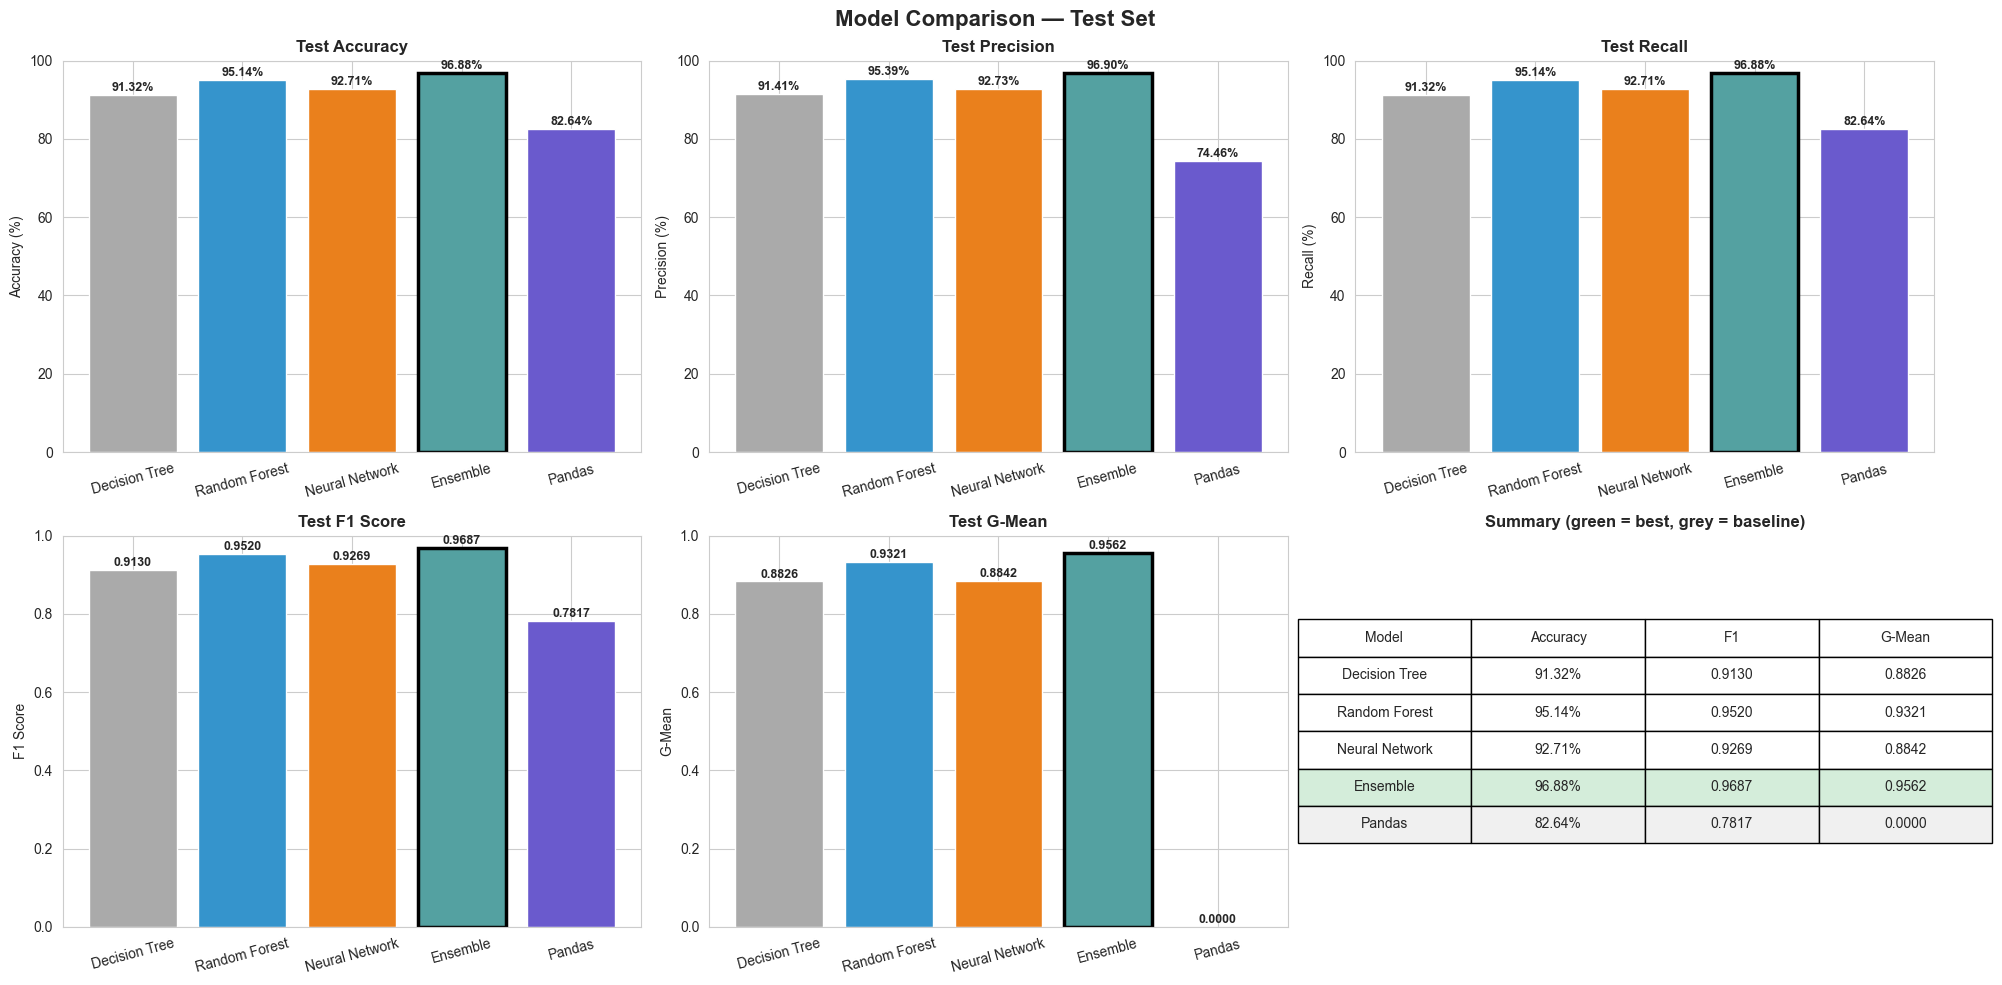


MODEL SELECTION SUMMARY

Decision Tree:
  Test Accuracy : 91.32%
  Test F1       : 0.9130
  Test G-Mean   : 0.8826

Random Forest:
  Test Accuracy : 95.14%
  Test F1       : 0.9520
  Test G-Mean   : 0.9321

Neural Network:
  Test Accuracy : 92.71%
  Test F1       : 0.9269
  Test G-Mean   : 0.8842

Ensemble:
  Test Accuracy : 96.88%
  Test F1       : 0.9687
  Test G-Mean   : 0.9562

Pandas ← baseline:
  Test Accuracy : 82.64%
  Test F1       : 0.7817
  Test G-Mean   : 0.0000

→ Best model by G-Mean   : Ensemble (0.9562)
→ Improvement over Pandas: +inf%


/var/folders/hg/fq57sy157xxf2tb_3b7nc79r0000gn/T/ipykernel_1135/2869729482.py:104: RuntimeWarning: divide by zero encountered in scalar divide
  improvement  = (best_gmean - pandas_gmean) / pandas_gmean * 100


In [17]:
best_nn_idx = results_df['best_val_metric'].idxmax()
best_nn_row = results_df.loc[best_nn_idx]

results = {
    'Decision Tree': dt_model.metrics,
    'Random Forest': rf_model.metrics,
    'Neural Network': {
        'test_accuracy':    best_nn_row['test_accuracy'],
        'test_precision':   best_nn_row['test_precision'],
        'test_recall':      best_nn_row['test_recall'],
        'test_f1score':     best_nn_row['test_f1score'],
        'test_gmean':       best_nn_row['test_gmean'],
        'confusion_matrix': best_nn_row['confusion_matrix'],
    },
    'Ensemble': {
        'test_accuracy':    best_nn.metrics['ensemble_test_accuracy'],
        'test_precision':   best_nn.metrics['ensemble_test_precision'],
        'test_recall':      best_nn.metrics['ensemble_test_recall'],
        'test_f1score':     best_nn.metrics['ensemble_test_f1score'],
        'test_gmean':       best_nn.metrics['ensemble_test_gmean'],
        'confusion_matrix': best_nn.metrics['ensemble_confusion_matrix'],
    },
    'Pandas': pandas_metrics,
}

colors = ['#aaaaaa', '#3594cc', '#ea801c', '#54a1a1', '#6a5acd']
models = list(results.keys())

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

metric_configs = [
    ('test_accuracy',  'Accuracy (%)',  'Test Accuracy',  '{:.2f}%', 1,    [0, 100]),
    ('test_precision', 'Precision (%)', 'Test Precision', '{:.2f}%', 1,    [0, 100]),
    ('test_recall',    'Recall (%)',    'Test Recall',    '{:.2f}%', 1,    [0, 100]),
    ('test_f1score',   'F1 Score',      'Test F1 Score',  '{:.4f}',  0.01, [0, 1]),
    ('test_gmean',     'G-Mean',        'Test G-Mean',    '{:.4f}',  0.01, [0, 1]),
]

for ax, (key, ylabel, title, fmt, offset, ylim) in zip(axes, metric_configs):
    values = [results[m][key] for m in models]
    bars   = ax.bar(models, values, color=colors)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(ylim)
    ax.tick_params(axis='x', rotation=15)
    for i, v in enumerate(values):
        ax.text(i, v + offset, fmt.format(v), ha='center', fontweight='bold', fontsize=9)
    best_idx = int(np.argmax(values))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)

# Summary table
ax = axes[5]
ax.axis('off')
table_data = [
    [m,
     f"{results[m]['test_accuracy']:.2f}%",
     f"{results[m]['test_f1score']:.4f}",
     f"{results[m]['test_gmean']:.4f}"]
    for m in models
]
table = ax.table(
    cellText=table_data,
    colLabels=['Model', 'Accuracy', 'F1', 'G-Mean'],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

gmeans   = [results[m]['test_gmean'] for m in models]
best_row = int(np.argmax(gmeans)) + 1
for col in range(4):
    table[best_row, col].set_facecolor('#d4edda')

pandas_row = list(models).index('Pandas') + 1
for col in range(4):
    table[pandas_row, col].set_facecolor('#f0f0f0')

ax.set_title('Summary (green = best, grey = baseline)', fontweight='bold')

plt.suptitle('Model Comparison — Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_bar.pdf', bbox_inches='tight', dpi=300)
plt.savefig('model_comparison_bar.png', bbox_inches='tight', dpi=300)
plt.show()

# Print summary
print("\n" + "=" * 50)
print("MODEL SELECTION SUMMARY")
print("=" * 50)
for m in models:
    tag = " ← baseline" if m == 'Pandas' else ""
    print(f"\n{m}{tag}:")
    print(f"  Test Accuracy : {results[m]['test_accuracy']:.2f}%")
    print(f"  Test F1       : {results[m]['test_f1score']:.4f}")
    print(f"  Test G-Mean   : {results[m]['test_gmean']:.4f}")

best_model   = models[int(np.argmax(gmeans))]
pandas_gmean = results['Pandas']['test_gmean']
best_gmean   = results[best_model]['test_gmean']
improvement  = (best_gmean - pandas_gmean) / pandas_gmean * 100

print(f"\n→ Best model by G-Mean   : {best_model} ({best_gmean:.4f})")
print(f"→ Improvement over Pandas: +{improvement:.1f}%")

### 6.4 Confusion Matrix Comparison (Main Models)

/var/folders/hg/fq57sy157xxf2tb_3b7nc79r0000gn/T/ipykernel_1135/3238662604.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


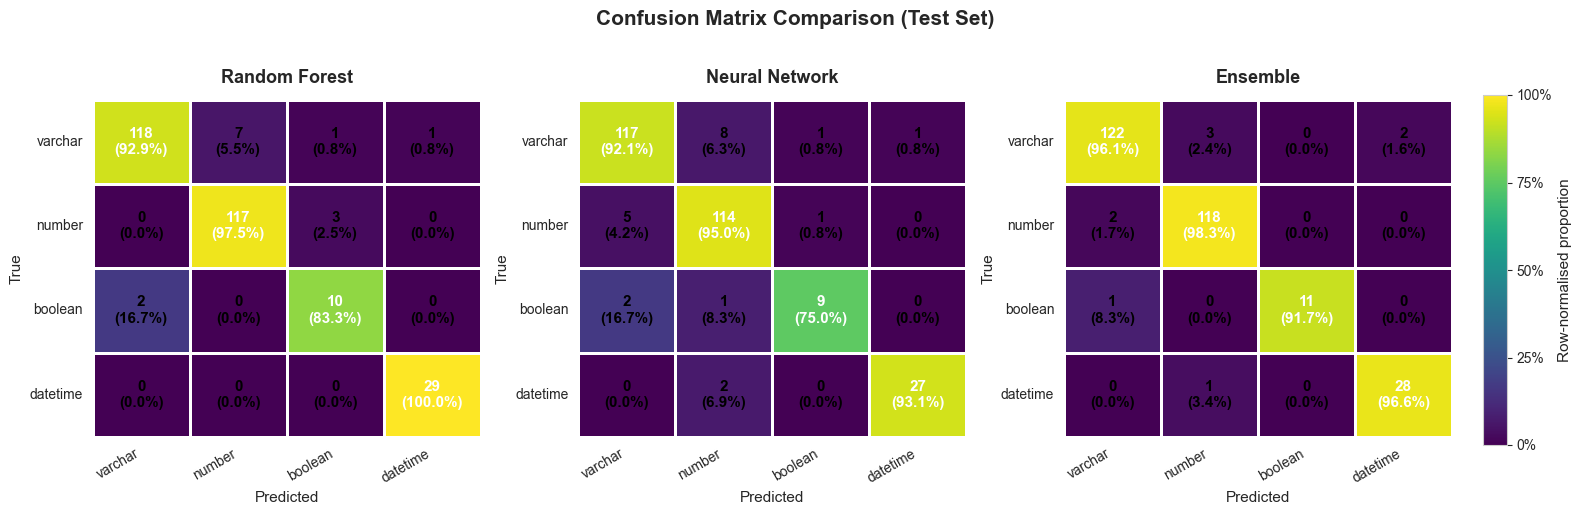

In [18]:
def plot_confusion_matrix_accessible(cm, class_names, model_name, ax):
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_normalized,
        annot=False,
        cmap='viridis',
        vmin=0, vmax=1,
        linewidths=0.8,
        linecolor='white',
        ax=ax,
        cbar=False,
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count      = cm[i, j]
            pct        = cm_normalized[i, j] * 100
            text_color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
            ax.text(
                j + 0.5, i + 0.5,
                f'{count}\n({pct:.1f}%)',
                ha='center', va='center',
                fontsize=11, fontweight='bold',
                color=text_color,
            )

    ax.set_title(model_name, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=10)
    ax.set_yticklabels(class_names, rotation=0, fontsize=10)


class_names = ['varchar', 'number', 'boolean', 'datetime']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, model_name in zip(axes, [ 'Random Forest', 'Neural Network', 'Ensemble']):
    plot_confusion_matrix_accessible(
        results[model_name]['confusion_matrix'],
        class_names, model_name, ax,
    )

cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Row-normalised proportion', fontsize=11)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])

plt.suptitle('Confusion Matrix Comparison (Test Set)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig('confusion_matrices_main.pdf', bbox_inches='tight', dpi=300)
plt.savefig('confusion_matrices_main.png', bbox_inches='tight', dpi=300)
plt.show()

## 7. Subnetwork Contributions in the Modular Neural Network

### 7.1 Statistics Subnetwork

In [19]:
print(f"\n{'='*70}")
print(f"Learning Rate: {best_lr}, Batch Size: {best_bs}")
print(f"{'='*70}\n")

stats_nn_model = StatsNeuralNetwork(criterion).to(device)
nn_model_training_pipeline(
    X_train, y_train, X_val, y_val, X_test, y_test, X_test_column,
    stats_nn_model, epochs=epochs, batch_size=best_bs,
    lr=best_lr, patience=20, weight_decay=5e-3, min_delta=0.001,
    monitor="val_gmean",
)


Learning Rate: 0.003, Batch Size: 1024

Epoch [1/500] - New best validation G-Mean: 0.2357
Epoch [2/500] - New best validation G-Mean: 0.5822
Epoch [10/500] - Train Loss: 1.3881, Train Acc: 53.65% | Val Loss: 1.4197, Val Acc: 44.84%, Val G-Mean(weighted): 0.5146 | No improve: 8/20
Epoch [11/500] - New best validation G-Mean: 0.6042
Epoch [12/500] - New best validation G-Mean: 0.6264
Epoch [13/500] - New best validation G-Mean: 0.6456
Epoch [20/500] - New best validation G-Mean: 0.6550
Epoch [20/500] - Train Loss: 1.3825, Train Acc: 48.01% | Val Loss: 1.3952, Val Acc: 61.73%, Val G-Mean(weighted): 0.6550 | No improve: 0/20
Epoch [21/500] - New best validation G-Mean: 0.6567
Epoch [30/500] - Train Loss: 1.3435, Train Acc: 53.02% | Val Loss: 1.3958, Val Acc: 46.34%, Val G-Mean(weighted): 0.5075 | No improve: 9/20
Epoch [40/500] - Train Loss: 1.3341, Train Acc: 54.90% | Val Loss: 1.3842, Val Acc: 51.42%, Val G-Mean(weighted): 0.5544 | No improve: 19/20
Early stopping triggered at epoch 41

StatsNeuralNetwork(
  (criterion): CrossEntropyLoss()
  (fc1): Linear(in_features=95, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_fc): Linear(in_features=64, out_features=4, bias=True)
)

### 7.2 Column Name Subnetwork

In [20]:
print(f"\n{'='*70}")
print(f"Learning Rate: {best_lr}, Batch Size: {best_bs}")
print(f"{'='*70}\n")

colname_nn_model = ColNameNeuralNetwork(criterion, dropout_rate=0.2).to(device)
nn_model_training_pipeline(
    X_train, y_train, X_val, y_val, X_test, y_test, X_test_column,
    colname_nn_model, epochs=epochs, batch_size=best_bs,
    lr=best_lr, patience=20, weight_decay=5e-3, min_delta=0.001,
    monitor="val_gmean",
)


Learning Rate: 0.003, Batch Size: 1024

Epoch [1/500] - New best validation G-Mean: 0.8373
Epoch [2/500] - New best validation G-Mean: 0.8521
Epoch [4/500] - New best validation G-Mean: 0.8793
Epoch [5/500] - New best validation G-Mean: 0.8925
Epoch [6/500] - New best validation G-Mean: 0.8979
Epoch [7/500] - New best validation G-Mean: 0.9043
Epoch [8/500] - New best validation G-Mean: 0.9070
Epoch [10/500] - Train Loss: 0.9761, Train Acc: 92.92% | Val Loss: 1.0113, Val Acc: 88.49%, Val G-Mean(weighted): 0.9054 | No improve: 2/20
Epoch [11/500] - New best validation G-Mean: 0.9254
Epoch [19/500] - New best validation G-Mean: 0.9278
Epoch [20/500] - Train Loss: 0.9478, Train Acc: 95.30% | Val Loss: 0.9901, Val Acc: 91.18%, Val G-Mean(weighted): 0.9282 | No improve: 1/20
Epoch [25/500] - New best validation G-Mean: 0.9292
Epoch [26/500] - New best validation G-Mean: 0.9344
Epoch [30/500] - Train Loss: 0.9367, Train Acc: 96.10% | Val Loss: 0.9959, Val Acc: 91.18%, Val G-Mean(weighted): 

ColNameNeuralNetwork(
  (criterion): CrossEntropyLoss()
  (fc1): Linear(in_features=200, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output_fc): Linear(in_features=128, out_features=4, bias=True)
)

In [21]:
subnn_results = {
    'Stats Neural Network':   stats_nn_model.metrics,
    'Col Name Neural Network': colname_nn_model.metrics,
}

for name, metrics in subnn_results.items():
    print(f"\n{name}:")
    print(f"  Test Accuracy : {metrics['test_accuracy']:.2f}%")
    print(f"  Test F1       : {metrics['test_f1score']:.4f}")
    print(f"  Test G-Mean   : {metrics['test_gmean']:.4f}")


Stats Neural Network:
  Test Accuracy : 61.46%
  Test F1       : 0.5550
  Test G-Mean   : 0.0000

Col Name Neural Network:
  Test Accuracy : 94.10%
  Test F1       : 0.9407
  Test G-Mean   : 0.8980
